In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import RFECV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing the functions from the prep_functions notebook

# Download the notebook from the URL
!wget https://raw.githubusercontent.com/gascalero/DM_II_project/refs/heads/master/notebooks/02_prep_functions.ipynb -O 02_prep_functions.ipynb

# Now run the downloaded notebook using the local path
get_ipython().run_line_magic('run', '-i "02_prep_functions.ipynb"')

# Check if the main functions and variables are imported correctly
print("Function imported correctly:")
print(f"- preprocess_train_df: {preprocess_train_df.__name__}")
print(f"- preprocess_test_df: {preprocess_test_df.__name__}")
print(f"- split_sets: {split_sets.__name__}")

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


Function imported correctly:
- preprocess_train_df: preprocess_train_df
- preprocess_test_df: preprocess_test_df
- split_sets: split_sets


# 1. INITIAL READING OF THE DATASET AND PREPROCESSING PIPELINES EXECUTION

In [3]:
# Reading CSV files with pandas

cancer_df = pd.read_csv('https://raw.githubusercontent.com/gascalero/DM_II_project/4a73ca4928f2b95f960cd9b9f44c4700244ed553/data/raw/patient_train_data.csv',
                        encoding='UTF-8',
                        index_col=0,
                        sep=',',
                        on_bad_lines='skip',
                        quoting=3)
cancer_df.head(1)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = split_sets(cancer_df)

Dimension of X_train: (60028, 30)
Dimension of X_test: (15007, 30)
Dimension of y_train: (60028,)
Dimension of y_test: (15007,)


In [4]:
# Running the preprocessing pipeline for the training set
X_train_processed, y_train_processed, mode_train, stats_pre, encoders = preprocess_train_df(X_train, y_train, columns_to_delete, values_to_imput_cat, binary_cols, ordinal_mappings, numeric_cols, categorical_cols)

# Running the preprocessing pipeline for the validation set

X_val_processed = preprocess_test_df(X_val, X_train_processed.columns, values_to_imput_cat, columns_to_delete, mode_train, stats_pre, binary_cols, numeric_cols, categorical_cols, encoders)

# y_val_processed = y_val.copy() for following the same convention as X_val_processed
y_val_processed = y_val.copy()

# 2. FEATURE SELECTION

## 2.1. SFS - Forward

In [ ]:
"""
lr = LogisticRegression(max_iter=500)
sbs_fwd = SFS(lr, direction='forward', scoring='accuracy', cv=None, n_features_to_select=15)
sbs_fwd.fit(X_train_processed, y_train_processed)
selected_features_SBS_fwd = feature_names[sbs_fwd.get_support()]
print(selected_features_SBS_fwd)
"""

['Alcohol Consumption' 'Cancer Stage' 'Diabetes' 'Diet Risk'
 'Early Detection' 'Family History' 'Gender' 'Genetic Mutation'
 'Healthcare Access' 'Healthcare Costs' 'Heart Disease History'
 'Incidence Rate per 100K' 'Inflammatory Bowel Disease'
 'Mortality Rate per 100K' 'Obesity BMI']


In [6]:
selected_features_SBS_fwd = [
    'Alcohol Consumption', 'Cancer Stage', 'Diabetes', 'Diet Risk',
    'Early Detection', 'Family History', 'Gender', 'Genetic Mutation',
    'Healthcare Access', 'Healthcare Costs', 'Heart Disease History',
    'Incidence Rate per 100K', 'Inflammatory Bowel Disease',
    'Mortality Rate per 100K', 'Obesity BMI'
]

## 2.1. SFS - Backward

In [ ]:
"""
feature_names = np.array(X_train_processed.columns)
lr = LogisticRegression(max_iter=500)
sbs_back = SFS(lr, direction='backward', scoring='f1_macro', cv=None, n_features_to_select=15)
sbs_back.fit(X_train_processed,y_train_processed)
selected_features_SBS_back = feature_names[sbs_back.get_support()]

print(selected_features_SBS_back)
"""

['Country_Nigeria' 'Country_Pakistan' 'Country_South Africa'
 'Country_South Korea' 'Country_UK' 'Country_USA'
 'Insurance Costs_Extended' 'Insurance Costs_No insurance'
 'Treatment Type_Combination' 'Treatment Type_Radiotherapy'
 'Treatment Type_Surgery' 'Hypertension_Yes' 'Insurance Status_Uninsured'
 'Non Smoker_Yes' 'Urban or Rural_Urban']


In [10]:
selected_features_SBS_back = [
    'Country_Nigeria', 'Country_Pakistan', 'Country_South Africa',
    'Country_South Korea', 'Country_UK', 'Country_USA',
    'Insurance Costs_Extended', 'Insurance Costs_No insurance',
    'Treatment Type_Combination', 'Treatment Type_Radiotherapy',
    'Treatment Type_Surgery', 'Hypertension_Yes', 'Insurance Status_Uninsured',
    'Non Smoker_Yes', 'Urban or Rural_Urban'
]

## 2.2. RFECV

In [ ]:
"""
estimator = LogisticRegression(max_iter=500)

rfecv_selector = RFECV(
    estimator=estimator,
    step=1,
    cv=5,
    scoring='f1_macro',
    min_features_to_select=15,
    n_jobs=-1
)

rfecv_selector.fit(X_train_processed, y_train_processed)

selected_mask = rfecv_selector.support_
selected_features_rfecv = X_train_processed.columns[selected_mask].tolist()
n_selected = len(selected_features_rfecv)

print(selected_features_rfecv)
"""

['Diabetes', 'Cardiometabolic_Risk', 'Country_Brazil', 'Country_Canada', 'Country_China', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Italy', 'Country_Japan', 'Country_Nigeria', 'Country_Pakistan', 'Country_South Korea', 'Country_USA', 'Treatment Type_Radiotherapy']


In [8]:
selected_features_rfecv = ['Diabetes', 'Cardiometabolic_Risk', 'Country_Brazil', 'Country_Canada', 
                           'Country_China', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Italy', 
                           'Country_Japan', 'Country_Nigeria', 'Country_Pakistan', 'Country_South Korea', 'Country_USA', 
                           'Treatment Type_Radiotherapy']

# 3. MODEL EVALUATION AND SELECTION (CROSS-VALIDATION)

This following function was built for evaluating models using Cross-Validation for different combinations of features according to the methods used in the previous section. It returns the average measures (F1 Macro) after running the trained model on each fold's validation set and training set. This helps provide an idea of possible overfitting.

The models used for cross-validation evaluation were:

- **Logistic Regression** (`LogisticRegression`)
- **Random Forest** (`RandomForestClassifier`)
- **Decision Tree** (`DecisionTreeClassifier`)

These models allow for performance comparison under different feature selection strategies and help identify the most robust and generalizable model for the survival prediction problem.

In [5]:
# Define initial models with default or basic parameters
models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
}

In [10]:
def evaluate_models_with_cv(
    X, y, models_dict, cv,
    columns_to_delete, values_to_imput_cat, binary_cols,
    ordinal_mappings, numeric_cols, categorical_cols, feature_selection=None,
    scoring='f1'
):
    cv_splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    f1_macro_scorer = make_scorer(f1_score)
    results = []

    for name, model in models_dict.items():
        val_scores = []
        train_scores = []

        for train_idx, val_idx in cv_splitter.split(X, y):
            X_train_fold, X_val_fold = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train_fold, y_val_fold = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            # Custom preprocessing for train
            X_train_proc, y_train_proc, mode_train, stats_pre, encoders = preprocess_train_df(
                X_train_fold, y_train_fold,
                columns_to_delete, values_to_imput_cat, binary_cols,
                ordinal_mappings, numeric_cols, categorical_cols, feature_selection
            )
            # Custom preprocessing for validation
            X_val_proc = preprocess_test_df(
                X_val_fold, X_train_proc.columns, values_to_imput_cat, columns_to_delete,
                mode_train, stats_pre, binary_cols, numeric_cols, categorical_cols, encoders
            )

            # Train and evaluate
            model_clone = clone(model)
            model_clone.fit(X_train_proc, y_train_proc)

            y_train_pred = model_clone.predict(X_train_proc)
            train_f1 = f1_score(y_train_proc, y_train_pred, average='macro')
            train_scores.append(train_f1)

            y_val_pred = model_clone.predict(X_val_proc)
            val_f1 = f1_score(y_val_fold, y_val_pred, average='macro')
            val_scores.append(val_f1)

        val_scores = np.array(val_scores)
        train_scores = np.array(train_scores)

        results.append({
            'Model': name,
            'Mean score (Val)': val_scores.mean(),
            'Std score (Val)': val_scores.std(),
            'Min score (Val)': val_scores.min(),
            'Max score (Val)': val_scores.max(),
            'Mean score (Train)': train_scores.mean(),
            'Std score (Train)': train_scores.std(),
            'Overfit Gap': train_scores.mean() - val_scores.mean(),
            'Val Scores': val_scores,
            'Train Scores': train_scores
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Mean score (Val)', ascending=False)
    return results_df

After the functions for cross-validation are designed, we execute them.

In [ ]:
"""
# Evaluate models with all features

cv = 10 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train, y_train, models, cv, columns_to_delete, values_to_imput_cat, binary_cols, ordinal_mappings, numeric_cols, categorical_cols)

# Show results
cv_results[['Model', 'Mean score (Train)', 'Std score (Train)', 'Mean score (Val)', 'Std score (Val)' ,'Overfit Gap']]
"""

,Model,Mean score (Train),Std score (Train),Mean score (Val),Std score (Val),Overfit Gap
0,LogisticRegression,0.508690,0.001353,0.495425,0.005507,0.013264
1,RandomForest,0.559374,0.002601,0.495053,0.003514,0.064320
2,DecisionTree,0.485891,0.025919,0.474777,0.027289,0.011113


In [ ]:
# SBS Forward Selection
"""
cv = 10 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train, y_train, models, cv, columns_to_delete, values_to_imput_cat, binary_cols, ordinal_mappings, numeric_cols, categorical_cols, selected_features_SBS_fwd)

# Show results
cv_results[['Model', 'Mean score (Train)', 'Std score (Train)', 'Mean score (Val)', 'Std score (Val)' ,'Overfit Gap']]

"""

,Model,Mean score (Train),Std score (Train),Mean score (Val),Std score (Val),Overfit Gap
1,RandomForest,0.543541,0.003005,0.494273,0.004159,0.049268
0,LogisticRegression,0.499250,0.001346,0.492801,0.006779,0.006449
2,DecisionTree,0.470631,0.030112,0.458910,0.028113,0.011721


In [ ]:
# SBS Backward Selection
"""
cv = 10 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train, y_train, models, cv, columns_to_delete, values_to_imput_cat, binary_cols, ordinal_mappings, numeric_cols, categorical_cols, selected_features_SBS_back)

# Show results
cv_results[['Model', 'Mean score (Train)', 'Std score (Train)', 'Mean score (Val)', 'Std score (Val)' ,'Overfit Gap']]
"""

,Model,Mean score (Train),Std score (Train),Mean score (Val),Std score (Val),Overfit Gap
1,RandomForest,0.521459,0.001782,0.502373,0.005370,0.019086
0,LogisticRegression,0.506183,0.001892,0.500036,0.004715,0.006148
2,DecisionTree,0.504168,0.006851,0.494554,0.006673,0.009614


In [ ]:
#RFECV Selection
"""
cv = 10 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train, y_train, models, cv, columns_to_delete, values_to_imput_cat, binary_cols, ordinal_mappings, numeric_cols, categorical_cols, selected_features_rfecv)

# Show results
cv_results[['Model', 'Mean score (Train)', 'Std score (Train)', 'Mean score (Val)', 'Std score (Val)' ,'Overfit Gap']]
"""

,Model,Mean score (Train),Std score (Train),Mean score (Val),Std score (Val),Overfit Gap
0,LogisticRegression,0.505547,0.002988,0.498574,0.005368,0.006973
1,RandomForest,0.507297,0.004692,0.497457,0.007212,0.009840
2,DecisionTree,0.500810,0.003895,0.493951,0.005119,0.006859


**Explanation of Selected SBS Backward Features**

We picked SBS backward because it starts with all features and removes the least useful ones step by step, so we end up with only the most important variables. This helps avoid overfitting and makes the model more generalizable, especially when there are lots of features to begin with. Compared to other methods, it gave us the best cross-validation results, so it was the most reliable choice for our dataset.

The 15 features selected by SBS backward selection represent a mix of demographic, socioeconomic, treatment, and health-related variables. Here’s what each group adds:

- **Country-related features** (`Country_Nigeria`, `Country_Pakistan`, `Country_South Africa`, `Country_South Korea`, `Country_UK`, `Country_USA`):  
    Capture geographic and healthcare system differences, reflecting disparities in access, treatment standards, and population health profiles.

- **Insurance and cost features** (`Insurance Costs_Extended`, `Insurance Costs_No insurance`, `Insurance Status_Uninsured`):  
    Indicate the patient’s financial protection and access to care, which can strongly influence outcomes.

- **Treatment type features** (`Treatment Type_Combination`, `Treatment Type_Radiotherapy`, `Treatment Type_Surgery`):  
    Represent the main modalities of cancer treatment, directly impacting survival chances.

- **Health status features** (`Hypertension_Yes`, `Non Smoker_Yes`):  
    Reflect comorbidities and lifestyle factors that affect prognosis and recovery.

- **Urbanization** (`Urban or Rural_Urban`):  
    Suggests differences in healthcare access, environmental exposures, and support systems between urban and rural settings.

Together, these features provide a comprehensive view of the patient’s context, treatment, and health status, enabling models to generalize well and make robust survival predictions.


In [11]:
X_train_selected = X_train_processed[selected_features_SBS_back]
X_val_selected = X_val_processed[selected_features_SBS_back]

# 4. HYPERPARAMETERS OPTIMIZATION

After evaluating several models, we selected Logistic Regression and Random Forest as our primary candidates. Both models demonstrated strong generalization performance and stability across cross-validation folds. Logistic Regression offers interpretability and robustness, while Random Forest provides the ability to capture complex, non-linear relationships and handles feature interactions well.

We also considered Decision Tree models. However, despite their interpretability, Decision Trees often shows a clear tendency to overfit the training data. This overfitting reduces their reliability and generalizability on unseen data, making them less suitable for our final model selection.

In addition to individual models, we further explored ensemble methods such as AdaBoost, Voting Classifier, and Stacking Classifier. These approaches combine the strengths of multiple base learners to improve predictive performance and robustness. Ensemble models often help reduce variance and bias, and in our experiments, they provided competitive results, sometimes outperforming single models. This comprehensive evaluation ensures that our final submission leverages the most reliable and generalizable approach for survival prediction.

## 4.1. LOGISTIC REGRESSION

In [ ]:
"""
param_grid = {
    'C': [0.01, 0.1, 1, 10, 20, 50, 100],
    'penalty': ['l1','l2'],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'class_weight': [{0: 1.5, 1: 1},'balanced'],
    'max_iter': [1000000]
}

# Create the classifier
LR_class = LogisticRegression(random_state=42)

# Define the scoring function
scorer = make_scorer(f1_score, average='macro')

# Configure GridSearchCV
grid_search = GridSearchCV(
    estimator=LR_class,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

# Fit the model with the training data
grid_search.fit(X_train_selected, y_train_processed)

# Show best parameters and scores
print("Best parameters:")
print(grid_search.best_params_)
print(f"Best F1 score: {grid_search.best_score_:.4f}")
"""

Best parameters:
{'C': 1, 'class_weight': {0: 1.5, 1: 1}, 'max_iter': 1000000, 'penalty': 'l1', 'solver': 'saga'}
Best F1 score: 0.5034


In [12]:
# Create model with the best parameters

best_log_reg = LogisticRegression(C= 1, class_weight= {0: 1.5, 1: 1}, max_iter = 1000000, penalty= 'l1', solver = 'saga', random_state=42)
# Train the model with the best parameters on the entire training set
best_log_reg.fit(X_train_selected, y_train_processed)
# Evaluate the model on the validation set
y_pred_best_LR = best_log_reg.predict(X_val_selected)
print("\nClassification report with best parameters (validation set):")
print(classification_report(y_val_processed, y_pred_best_LR))
# Evaluate the model on the training set
y_pred_best_train_LR = best_log_reg.predict(X_train_selected)
print("\nClassification report with best parameters (training set):")
print(classification_report(y_train_processed, y_pred_best_train_LR))


Classification report with best parameters (validation set):
              precision    recall  f1-score   support

           0       0.40      0.44      0.42      5993
           1       0.60      0.56      0.58      9014

    accuracy                           0.51     15007
   macro avg       0.50      0.50      0.50     15007
weighted avg       0.52      0.51      0.52     15007


Classification report with best parameters (training set):
              precision    recall  f1-score   support

           0       0.41      0.45      0.43     23665
           1       0.61      0.56      0.58     35531

    accuracy                           0.52     59196
   macro avg       0.51      0.51      0.51     59196
weighted avg       0.53      0.52      0.52     59196



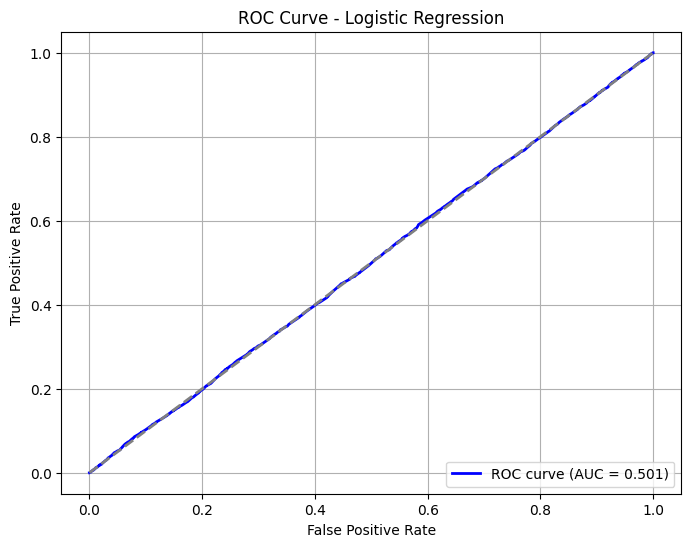

In [13]:
y_val_proba = best_log_reg.predict_proba(X_val_selected)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val_processed, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 4.2. RANDOM FOREST

In [ ]:
"""
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__class_weight': [{0: 1.5, 1: 1}, 'balanced']
}

pipeline_rf = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define the scoring function
scorer = make_scorer(f1_score, average='macro')

# Configure GridSearchCV
# Use the pipeline and the parameter grid for Random Forest
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring=scorer,
    cv=10,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

# Fit the model with the training data
grid_search_rf.fit(X_train_selected, y_train_processed)

# Show best parameters and scores
print("Best parameters:")
print(grid_search_rf.best_params_)
print(f"Best F1 score: {grid_search_rf.best_score_:.4f}")
"""

Best parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best F1 score: 0.5023


In [14]:
# Create model with the best parameters

best_rf = RandomForestClassifier(class_weight= 'balanced', max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100, random_state=42)

# Train the model with the best parameters on the entire training set
best_rf.fit(X_train_selected, y_train_processed)

# Evaluate the model on the validation set
y_pred_best_RF = best_rf.predict(X_val_selected)
print("\nClassification report with best parameters:")
print(classification_report(y_val_processed, y_pred_best_RF))

# Evaluate the model on the training set
y_pred_best_train_RF = best_rf.predict(X_train_selected)
print("\nClassification report with best parameters (training set):")
print(classification_report(y_train_processed, y_pred_best_train_RF))


Classification report with best parameters:
              precision    recall  f1-score   support

           0       0.40      0.49      0.44      5993
           1       0.61      0.52      0.56      9014

    accuracy                           0.51     15007
   macro avg       0.51      0.51      0.50     15007
weighted avg       0.53      0.51      0.51     15007


Classification report with best parameters (training set):
              precision    recall  f1-score   support

           0       0.44      0.53      0.48     23665
           1       0.64      0.55      0.59     35531

    accuracy                           0.54     59196
   macro avg       0.54      0.54      0.54     59196
weighted avg       0.56      0.54      0.55     59196



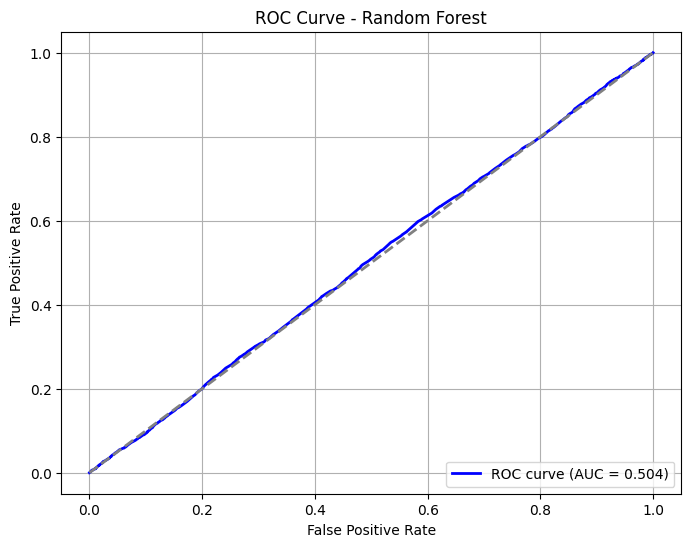

In [15]:
y_val_proba = best_rf.predict_proba(X_val_selected)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val_processed, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 4.3. ADABOOST

In [16]:
"""
base_estimator = DecisionTreeClassifier(
    max_depth=2,
    class_weight={0: 1.5, 1: 1}
)

param_grid_ada = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.001, 0.01, 0.1, 1],
    'estimator__max_depth': [1, 2, 3],
    'estimator__class_weight': [{0: 1.5, 1: 1}, 'balanced']
}

scorer = make_scorer(f1_score, average='macro')
grid_search_ada = GridSearchCV(
    estimator=AdaBoostClassifier(
        estimator=base_estimator,
        random_state=42
    ),
    param_grid=param_grid_ada,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search_ada.fit(X_train_selected, y_train_processed)

print("Best parameters:")
print(grid_search_ada.best_params_)
print(f"Best F1 score: {grid_search_ada.best_score_:.4f}")

best_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=grid_search_ada.best_params_['estimator__max_depth'],
        class_weight=grid_search_ada.best_params_['estimator__class_weight']
    ),
    n_estimators=grid_search_ada.best_params_['n_estimators'],
    learning_rate=grid_search_ada.best_params_['learning_rate'],
    random_state=42
)
best_ada.fit(X_train_selected, y_train_processed)
"""""

'\nbase_estimator = DecisionTreeClassifier(\n    max_depth=2,\n    class_weight={0: 1.5, 1: 1}\n)\n\nparam_grid_ada = {\n    \'n_estimators\': [100, 200, 300, 400],\n    \'learning_rate\': [0.001, 0.01, 0.1, 1],\n    \'estimator__max_depth\': [1, 2, 3],\n    \'estimator__class_weight\': [{0: 1.5, 1: 1}, \'balanced\']\n}\n\nscorer = make_scorer(f1_score, average=\'macro\')\ngrid_search_ada = GridSearchCV(\n    estimator=AdaBoostClassifier(\n        estimator=base_estimator,\n        random_state=42\n    ),\n    param_grid=param_grid_ada,\n    scoring=scorer,\n    cv=5,\n    n_jobs=-1,\n    verbose=1,\n    return_train_score=True\n)\n\ngrid_search_ada.fit(X_train_selected, y_train_processed)\n\nprint("Best parameters:")\nprint(grid_search_ada.best_params_)\nprint(f"Best F1 score: {grid_search_ada.best_score_:.4f}")\n\nbest_ada = AdaBoostClassifier(\n    estimator=DecisionTreeClassifier(\n        max_depth=grid_search_ada.best_params_[\'estimator__max_depth\'],\n        class_weight=grid_

In [17]:
base_estimator = DecisionTreeClassifier(
    max_depth=2,
    class_weight={0: 1.5, 1: 1}
)

best_ada_par = AdaBoostClassifier(estimator=base_estimator, learning_rate = 0.1, n_estimators = 100)

# Fit the model before predicting
best_ada_par.fit(X_train_selected, y_train_processed)

y_pred_best_ada = best_ada_par.predict(X_val_selected)
print("\nClassification report with best parameters (validation set):")
print(classification_report(y_val_processed, y_pred_best_ada))

y_pred_best_train_ada = best_ada_par.predict(X_train_selected)
print("\nClassification report with best parameters (training set):")
print(classification_report(y_train_processed, y_pred_best_train_ada))



Classification report with best parameters (validation set):
              precision    recall  f1-score   support

           0       0.39      0.39      0.39      5993
           1       0.60      0.61      0.60      9014

    accuracy                           0.52     15007
   macro avg       0.50      0.50      0.50     15007
weighted avg       0.52      0.52      0.52     15007


Classification report with best parameters (training set):
              precision    recall  f1-score   support

           0       0.42      0.41      0.41     23665
           1       0.61      0.62      0.61     35531

    accuracy                           0.53     59196
   macro avg       0.51      0.51      0.51     59196
weighted avg       0.53      0.53      0.53     59196



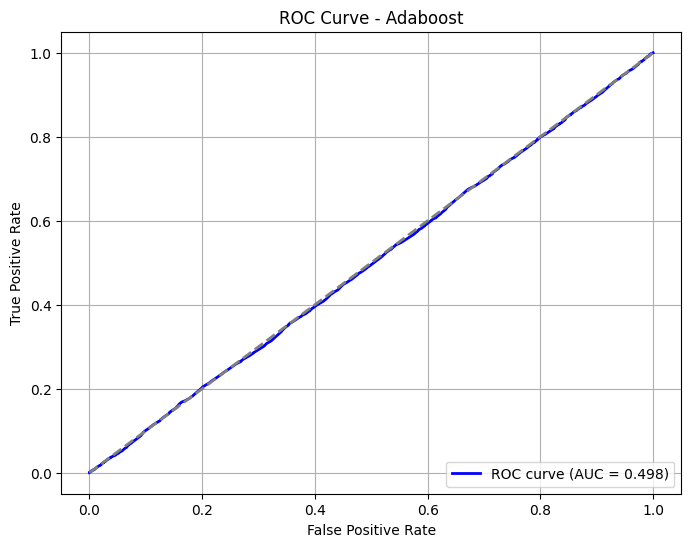

In [18]:
y_val_proba = best_ada_par.predict_proba(X_val_selected)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val_processed, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Adaboost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 5. ENSAMBLE METHODS

## 5.2. STACKING CLASSIFIER

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
"""
base_dt = DecisionTreeClassifier(
    max_depth=3,
    class_weight={0: 1.1, 1: 1}
)

estimators = [
    ('lr', LogisticRegression(C=0.1, class_weight='balanced', max_iter=100000,
                             penalty='l1', solver='saga', random_state=42)),
    ('rf', RandomForestClassifier(class_weight={0: 1.5, 1: 1}, max_depth=10,
                                 min_samples_leaf=1, min_samples_split=2,
                                 n_estimators=300, random_state=42)),
    ('ada', AdaBoostClassifier(estimator=base_dt, n_estimators=300,
                              learning_rate=0.01,
                              random_state=42))
]

# Define the stacking classifier
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight={0: 1.5, 1: 1}, max_iter=10000, random_state=42),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

# Fit the stacking model
stack_model.fit(X_train_selected, y_train_processed)

# Validation set predictions
y_pred_stack = stack_model.predict(X_val_selected)
print("\nClassification report for Stacking Classifier:")
print(classification_report(y_val_processed, y_pred_stack))

# Training set predictions
y_pred_train_stack = stack_model.predict(X_train_selected)
print("\nClassification report for Stacking Classifier (training set):")
print(classification_report(y_train_processed, y_pred_train_stack))
"""


Classification report for Stacking Classifier:
              precision    recall  f1-score   support

           0       0.40      0.49      0.44      5993
           1       0.60      0.52      0.56      9014

    accuracy                           0.51     15007
   macro avg       0.50      0.50      0.50     15007
weighted avg       0.52      0.51      0.51     15007


Classification report for Stacking Classifier (training set):
              precision    recall  f1-score   support

           0       0.44      0.54      0.48     23665
           1       0.64      0.55      0.59     35531

    accuracy                           0.54     59196
   macro avg       0.54      0.54      0.54     59196
weighted avg       0.56      0.54      0.55     59196


Classification report for Stacking Classifier (training set):
              precision    recall  f1-score   support

           0       0.44      0.54      0.48     23665
           1       0.64      0.55      0.59     35531

    accu

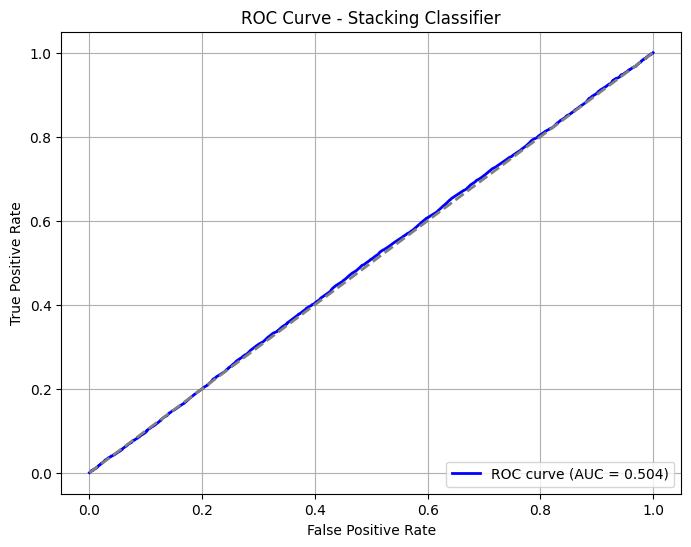

In [ ]:
y_val_proba = stack_model.predict_proba(X_val_processed[selected_features_SBS_back])[:, 1]

fpr, tpr, thresholds = roc_curve(y_val_processed, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacking Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 5.3. VOTING CLASSIFIER

In [19]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier

base_dt = DecisionTreeClassifier(
    max_depth=2,
    class_weight={0: 1.5, 1: 1}
)

estimators = [
    ('lr', LogisticRegression(C= 1, class_weight= {0: 1.5, 1: 1}, max_iter = 1000000, penalty= 'l1', solver = 'saga', random_state=42)),
    ('rf', RandomForestClassifier(class_weight= 'balanced', max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100, random_state=42)),
    ('ada', AdaBoostClassifier(estimator=base_dt, learning_rate = 0.1, n_estimators = 100))
]


voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=[3, 0, 2],
    n_jobs=-1
)

voting_clf.fit(X_train_selected, y_train_processed)

y_pred_voting = voting_clf.predict(X_val_selected)
print("\nClassification report for Voting Classifier (validation set):")
print(classification_report(y_val_processed, y_pred_voting))

y_pred_train_voting = voting_clf.predict(X_train_selected)
print("\nClassification report for Voting Classifier (training set):")
print(classification_report(y_train_processed, y_pred_train_voting))


Classification report for Voting Classifier (validation set):
              precision    recall  f1-score   support

           0       0.40      0.43      0.42      5993
           1       0.60      0.57      0.59      9014

    accuracy                           0.51     15007
   macro avg       0.50      0.50      0.50     15007
weighted avg       0.52      0.51      0.52     15007


Classification report for Voting Classifier (training set):
              precision    recall  f1-score   support

           0       0.41      0.45      0.43     23665
           1       0.61      0.57      0.59     35531

    accuracy                           0.52     59196
   macro avg       0.51      0.51      0.51     59196
weighted avg       0.53      0.52      0.52     59196



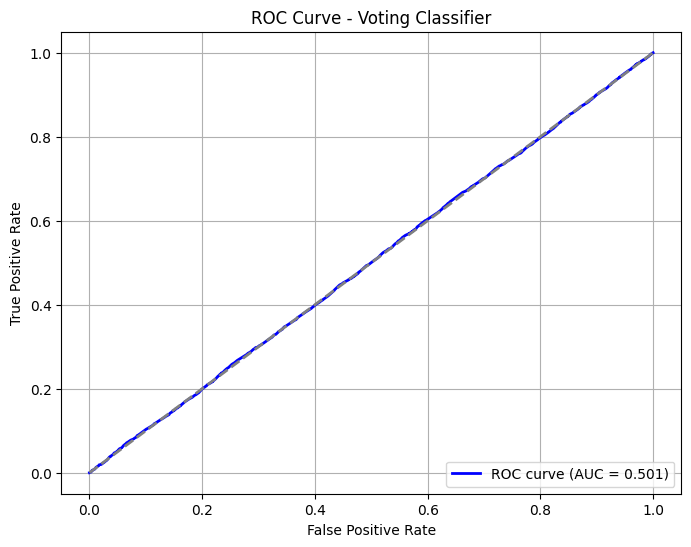

In [20]:
y_val_proba = voting_clf.predict_proba(X_val_selected)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val_processed, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Voting Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

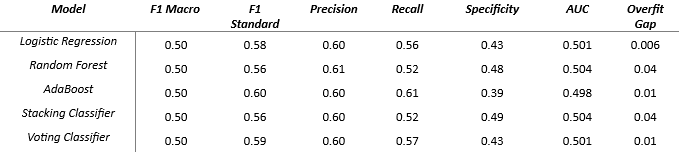

We ultimately chose the Voting Classifier as our final model because it provided the best trade-off between minimizing false positives and delivering stable predictions. Achieving a precision of 0.60 and a very small overfitting gap (0.01), it performed consistently across both training and test sets. Although Random Forest achieved a slightly higher precision (0.61) and the Stacking Classifier offered better specificity (0.49), both models exhibited greater overfitting (gaps of 0.04), making them less dependable for predicting outcomes in new patients.

# 6. DEPLOYMENT

After selecting the best model with its optimal hyperparameters, it is now time to create the final CSV for submission in the Kaggle competition.

In [30]:
# Importing the test dataset provided in the DM II project materials

test_cancer_df = pd.read_csv('https://raw.githubusercontent.com/gascalero/DM_II_project/refs/heads/master/data/raw/patient_test_data.csv',
                         encoding='UTF-8',
                         index_col=0,
                         sep=',',
                         on_bad_lines='skip',
                         quoting=3)

test_cancer_df.head(1)

# Executing the preprocessing pipeline for the final test set

X_test_processed = preprocess_test_df(test_cancer_df, X_train_processed.columns, values_to_imput_cat, columns_to_delete, mode_train, stats_pre, binary_cols, numeric_cols, categorical_cols, encoders)

In [32]:
y_pred_voting = voting_clf.predict(X_test_processed[selected_features_SBS_back])
# Creating the DataFrame for Kaggle submission
df_kaggle_voting = pd.DataFrame(y_pred_voting, index=test_cancer_df.index)
df_kaggle_voting.replace({0: 'No', 1: 'Yes'}, inplace = True)
df_kaggle_voting.columns = ['Survival Prediction']
df_kaggle_voting.value_counts()

Survival Prediction
Yes                    42734
No                     32266
Name: count, dtype: int64

In [ ]:
import os
# Exporting the DataFrame to a CSV file for submission
# Modify the file name as needed with the corresponding version number
output_dir = './data/Kaggle submissions'
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist
df_kaggle_voting.to_csv(f'{output_dir}/DT_Group05_VersionXX.csv')